## 1. Introduction

**Project title:** `AI Impact on Students: Burnout and GPA Prediction`  
**Student name:** `Aditya Makkar`  
**Module:** `M505 Intro to AI and Machine Learning`  
**Github Repo** https://github.com/AdityaMakkarr/IntrotoML_StudentGPAandBurnoutRisk_MLProject

**Dataset / stakeholder:** Educational institutions and student support teams

* **Background:** GEN AI tools, and AI in general has become an integral part of students lives. More than 50-60% of students report using AI for their highschool coursework. Kids use it to complete their homework for them, all the way to creating personal tutors which will help them crack exams. It's undeniable that this trend is going to even deepen further, and the use of AI will continue increasing over time. 

* **Problem Statement:** The usage of AI has an impact on a students Burnout rate, and their GPA. This project aims to study this relationship and build models to predict student outcomes.

* **Objective/Motivation:** As a Machine Learning Engineer, I intent to perform various models upon this dataset to understand the features effecting burnout rate and GPA of a student. Moreover, based on existing data, I can use that to predict a students GPA and Burnout risk. 

* **Machine Learning Tasks:** This project uses classification to predict `Burnout_Risk_Level` and regression to predict `Post_Semester_GPA`.



## 2. Data Collection

**Dataset source:** `Kaggle - AI Impact on Students` by NAGI SISIRO 

**Download information:** The dataset was manually downloaded from Kaggle(ZIP File) as a CSV file and loaded into this notebook.

**Dataset link:** `https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students`

* **Dataset Overview:** This dataset contains information(50000 values) related to Generative AI usage, study habits, academic performance, anxiety levels, and burnout risk. The dataset is taken from Kaggle and has 16 different features. These are both numerical and categorical features, serving as the perfect foundation for this project. Moreover, I will perform feature engineering, and add some features to have a wider set of data to use.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("ai_student_impact_dataset (1).csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 3. Exploratory Data Analysis

This section checks and then returns the dataset shape, feature types, missing values, target distribution, and descriptive statistics.

### 3.1 Dataset Description

In [3]:
import matplotlib.pyplot as plt

print("Dataset Shape:")
print(df.shape)

feature_desc = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum(),
    "Sample Value": df.iloc[0].astype(str)
})

print("\nFeature Description:")
display(feature_desc)

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe().T)



Dataset Shape:
(50000, 16)

Feature Description:


,Data Type,Unique Values,Missing Values,Sample Value
Student_ID,int64,50000,0,100001
Major_Category,object,5,0,Humanities
Year_of_Study,object,5,0,Senior
Pre_Semester_GPA,float64,2389,0,2.418
Weekly_GenAI_Hours,float64,3566,0,23.31
Primary_Use_Case,object,5,0,Copywriting/Drafting
Prompt_Engineering_Skill,object,3,0,Beginner
Tool_Diversity,int64,5,0,1
Paid_Subscription,bool,2,0,True
Traditional_Study_Hours,float64,2516,0,8.13



Duplicate Rows:
0

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Student_ID,50000.0,125000.500000,14433.901067,100001.000,112500.75000,125000.500,137500.250,150000.000
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


**Initial EDA Notes:**

* Dataset shape is 50000x16
* We have displayed all the features/columns and their details
* 0 Missing Values
* 0 Duplicate Rows

### 3.2 Target Variables Analysis

Burnout Risk Summary:


,Count,Percentage
Burnout_Risk_Level,,
Medium,21144,42.29
Low,16369,32.74
High,12487,24.97



Post-Semester GPA Summary:


,count,mean,std,min,25%,50%,75%,max,Missing Values,Unique Values
Post_Semester_GPA,50000.0,3.349299,0.495673,1.0,3.02375,3.421,3.749,4.0,0,2269


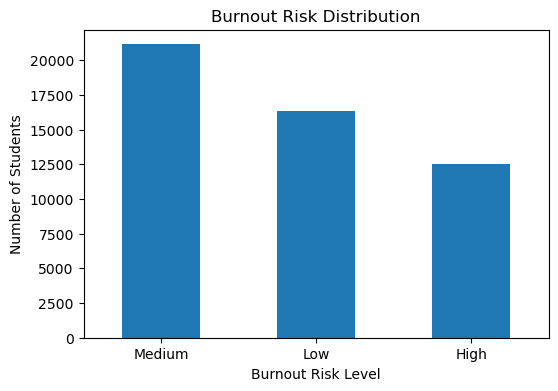

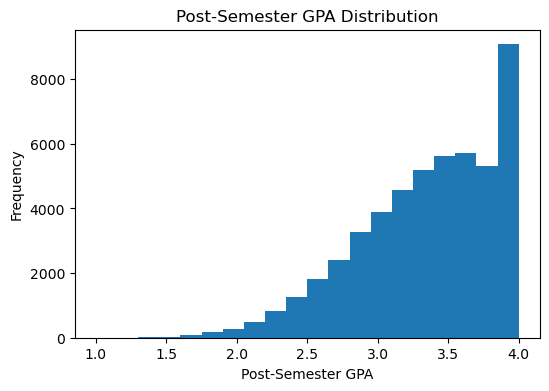

In [4]:
burnout_summary = pd.DataFrame({
    "Count": df["Burnout_Risk_Level"].value_counts(),
    "Percentage": (df["Burnout_Risk_Level"].value_counts(normalize=True) * 100).round(2)
})

print("Burnout Risk Summary:")
display(burnout_summary)

gpa_summary = df["Post_Semester_GPA"].describe().to_frame().T
gpa_summary["Missing Values"] = df["Post_Semester_GPA"].isnull().sum()
gpa_summary["Unique Values"] = df["Post_Semester_GPA"].nunique()

print("\nPost-Semester GPA Summary:")
display(gpa_summary)

plt.figure(figsize=(6, 4))
df["Burnout_Risk_Level"].value_counts().plot(kind="bar")
plt.title("Burnout Risk Distribution")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(6, 4))
df["Post_Semester_GPA"].plot(kind="hist", bins=20)
plt.title("Post-Semester GPA Distribution")
plt.xlabel("Post-Semester GPA")
plt.ylabel("Frequency")
plt.show()

**Target Variables EDA Notes**

* Medium burnout is highest, High Burnout is the lowest
* Average GPA is around 3.35
* GPA values are mostly high

## 4. Data Cleaning and Feature Engineering

**Encoding:** Categorical columns will be changed using `OneHotEncoder`.

**Scaling:** Numerical columns will be scaled using `StandardScaler`.

**Feature engineering:** Three new columns are added:

* `AI_Study_Ratio`
* `High_AI_Dependency`
* `AI_Usage_Level`

These features will help me show AI usage behaviour more clearly, and help us have better data to perform our ML models on. 

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df_cleaned = df.copy()

df_cleaned["AI_Study_Ratio"] = (
    df_cleaned["Weekly_GenAI_Hours"] / df_cleaned["Traditional_Study_Hours"]
).round(2)

df_cleaned["High_AI_Dependency"] = df_cleaned["Perceived_AI_Dependency"] >= 7

df_cleaned["AI_Usage_Level"] = pd.cut(
    df_cleaned["Weekly_GenAI_Hours"],
    bins=[-0.01, 5, 15, float("inf")],
    labels=["Low", "Medium", "High"]
)

display(df_cleaned[[
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "AI_Study_Ratio",
    "High_AI_Dependency",
    "AI_Usage_Level"
]].head())

,Weekly_GenAI_Hours,Traditional_Study_Hours,AI_Study_Ratio,High_AI_Dependency,AI_Usage_Level
0,23.31,8.13,2.87,False,High
1,1.12,16.65,0.07,False,Low
2,21.26,10.35,2.05,False,High
3,1.82,15.23,0.12,False,Low
4,9.29,12.55,0.74,False,Medium


**Feature Engineering Notes:**


**Missing values:** The dataset on its intial EDA showed 0 for missing values. Since there were 0 missing values, no imputation is needed.

**Feature engineering:** I added 3 new features to improve the analysis: `AI_Study_Ratio`, `High_AI_Dependency`, and `AI_Usage_Level`.

**Encoding:** Ordered categorical features(Ordinal Features) were handled using ordinal encoding, while unordered categorical features(nomimal) were handled using one-hot encoding.

**Scaling:** All the numerical features were scaled using `StandardScaler` so that models are not affected by the diffrenet ranges of values.

**Preprocessing pipeline:** I made a `ColumnTransformer` to apply different preprocessing steps to numerical, boolean, ordinal, and nominal features.

## 5. Data Engineering Comparison

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_regression = df_cleaned.drop(columns=[
    "Student_ID",
    "Skill_Retention_Score",
    "Burnout_Risk_Level",
    "Post_Semester_GPA"
])

y_regression = df_cleaned["Post_Semester_GPA"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_regression,
    y_regression,
    test_size=0.2,
    random_state=42
)

def regression_preprocessor(scaling=False):
    num_cols = X_regression.select_dtypes(include=["int64", "float64"]).columns.tolist()
    bool_cols = X_regression.select_dtypes(include=["bool"]).columns.tolist()
    cat_cols = X_regression.select_dtypes(include=["object", "category"]).columns.tolist()
    num_step = StandardScaler() if scaling else "passthrough"
    
    return ColumnTransformer(transformers=[
        ("num", num_step, num_cols),
        ("bool", "passthrough", bool_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

engineering_strategies = {
    "OneHot only": regression_preprocessor(False),
    "OneHot + StandardScaler": regression_preprocessor(True),
    "OneHot + StandardScaler + SelectKBest": Pipeline(steps=[
        ("preprocessing", regression_preprocessor(True)),
        ("feature_selection", SelectKBest(score_func=f_regression, k=20))
    ])
}

engineering_results = []

for strategy_name, preprocessing_step in engineering_strategies.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessing_step),
        ("model", Ridge(alpha=1.0))
    ])
    
    model_pipeline.fit(Xr_train, yr_train)
    y_pred = model_pipeline.predict(Xr_test)
    
    engineering_results.append({
        "Strategy": strategy_name,
        "MAE": round(mean_absolute_error(yr_test, y_pred), 4),
        "RMSE": round(mean_squared_error(yr_test, y_pred) ** 0.5, 4),
        "R2 Score": round(r2_score(yr_test, y_pred), 4)
    })

engineering_results_df = pd.DataFrame(engineering_results)

display(engineering_results_df.sort_values(by="R2 Score", ascending=False))

,Strategy,MAE,RMSE,R2 Score
0,OneHot only,0.1234,0.1571,0.8977
1,OneHot + StandardScaler,0.1234,0.1571,0.8977
2,OneHot + StandardScaler + SelectKBest,0.1238,0.1575,0.8973


**Data Engineering Comparison Notes:**

All three preprocessing strategies produced very similar results. This was because they used the same dataset, target variables, and models.
 The preprocessing methods we apply changes how the data is shown but it doesnt not add any new infornmation. Moreover, since the numerical values are not too diff(ex- age is from 10 to 100, but income is from 0 to 1000000), scaling doesn't have much of a difference either.


## 6. Model Training

**Selected preprocessing:** Strategy A was used because it gave the best result in the data engineering comparison.

**Classification task:** The target variable is `Burnout_Risk_Level`.

**Regression task:** The target variable is `Post_Semester_GPA`.

**Pipeline implementation:** Each model is trained inside a scikit-learn pipeline with preprocessing and model training combined.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score

X_regression = df_cleaned.drop(columns=[
    "Student_ID",
    "Skill_Retention_Score",
    "Burnout_Risk_Level",
    "Post_Semester_GPA"
])

y_regression = df_cleaned["Post_Semester_GPA"]

X_classification = df_cleaned.drop(columns=[
    "Student_ID",
    "Skill_Retention_Score",
    "Post_Semester_GPA",
    "Burnout_Risk_Level"
])

y_classification = df_cleaned["Burnout_Risk_Level"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_regression,
    y_regression,
    test_size=0.2,
    random_state=42
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_classification,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

def build_training_preprocessor(X_data):
    num_cols = X_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
    bool_cols = X_data.select_dtypes(include=["bool"]).columns.tolist()
    cat_cols = X_data.select_dtypes(include=["object", "category"]).columns.tolist()
    
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols),
        ("bool", "passthrough", bool_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Extra Trees Regressor": ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

regression_results = []

for model_name, model in regression_models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessing", build_training_preprocessor(X_regression)),
        ("model", model)
    ])
    
    model_pipeline.fit(Xr_train, yr_train)
    y_pred = model_pipeline.predict(Xr_test)
    
    regression_results.append({
        "Model": model_name,
        "MAE": round(mean_absolute_error(yr_test, y_pred), 4),
        "RMSE": round(mean_squared_error(yr_test, y_pred) ** 0.5, 4),
        "R2 Score": round(r2_score(yr_test, y_pred), 4)
    })

regression_results_df = pd.DataFrame(regression_results)

print("Regression Model Results:")
display(regression_results_df.sort_values(by="R2 Score", ascending=False))

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

classification_results = []

for model_name, model in classification_models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessing", build_training_preprocessor(X_classification)),
        ("model", model)
    ])
    
    model_pipeline.fit(Xc_train, yc_train)
    y_pred = model_pipeline.predict(Xc_test)
    
    classification_results.append({
        "Model": model_name,
        "Accuracy": round(accuracy_score(yc_test, y_pred), 4),
        "Macro F1": round(f1_score(yc_test, y_pred, average="macro"), 4)
    })

classification_results_df = pd.DataFrame(classification_results)

print("\nClassification Model Results:")
display(classification_results_df.sort_values(by="Macro F1", ascending=False))

Regression Model Results:


,Model,MAE,RMSE,R2 Score
2,Extra Trees Regressor,0.1198,0.1526,0.9035
1,Random Forest Regressor,0.1200,0.1537,0.9022
0,Linear Regression,0.1234,0.1571,0.8977



Classification Model Results:


,Model,Accuracy,Macro F1
0,Logistic Regression,0.5378,0.5377
1,Random Forest Classifier,0.5142,0.5175


**Model Training Insights:**

For regression, 3 models were used, and Extra Trees Regressor performed the best with an R² score of 0.9035 and RMSE of 0.1526.

For classification, 2 models were used, and Logistic Regression performed the best with an accuracy of 0.5378 and macro F1-score of 0.5377(better than baseline of majority class of 42%)

Overall, regression models performed much better than classification models, showing that `Post_Semester_GPA` was much easier to predict than `Burnout_Risk_Level`. This is probably also due to the fac thtat they're is low no. of feautres to help predict burnout, and that the faeture pre_gpa has strong correlation with post_gpa, so we get a high accuracy for the regression part of this analysis.


## 7. Hyperparameter Tuning

In [8]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import LogisticRegression

regression_focused_pipeline = Pipeline(steps=[
    ("preprocessing", build_training_preprocessor(X_regression)),
    ("model", ExtraTreesRegressor(random_state=42, n_jobs=1))
])

regression_focused_grid = {
    "model__n_estimators": [100, 150, 200, 250, 300],
    "model__max_depth": [15, 20, 25, 30, None],
    "model__min_samples_split": [2, 3, 5, 7],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": [0.7, 0.8, 0.9, 1.0]
}

regression_focused_search = RandomizedSearchCV(
    regression_focused_pipeline,
    param_distributions=regression_focused_grid,
    n_iter=20,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

regression_focused_search.fit(Xr_train, yr_train)

best_regression_model = regression_focused_search.best_estimator_

regression_focused_pred = best_regression_model.predict(Xr_test)

regression_focused_results = {
    "Best CV R2": round(regression_focused_search.best_score_, 4),
    "Test MAE": round(mean_absolute_error(yr_test, regression_focused_pred), 4),
    "Test RMSE": round(mean_squared_error(yr_test, regression_focused_pred) ** 0.5, 4),
    "Test R2": round(r2_score(yr_test, regression_focused_pred), 4)
}

print("Focused Regression Parameters:")
display(pd.DataFrame([regression_focused_search.best_params_]).T)

print("\nFocused Regression Results:")
display(pd.DataFrame([regression_focused_results]))

classification_focused_pipeline = Pipeline(steps=[
    ("preprocessing", build_training_preprocessor(X_classification)),
    ("model", LogisticRegression(max_iter=3000))
])

classification_focused_grid = {
    "model__C": [0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.5, 2.0],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["lbfgs"],
    "model__fit_intercept": [True, False]
}

classification_focused_search = GridSearchCV(
    classification_focused_pipeline,
    param_grid=classification_focused_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

classification_focused_search.fit(Xc_train, yc_train)

best_classification_model = classification_focused_search.best_estimator_

classification_focused_pred = best_classification_model.predict(Xc_test)

classification_focused_results = {
    "Best CV Macro F1": round(classification_focused_search.best_score_, 4),
    "Test Accuracy": round(accuracy_score(yc_test, classification_focused_pred), 4),
    "Test Macro F1": round(f1_score(yc_test, classification_focused_pred, average="macro"), 4)
}

print("\nFocused Classification Parameters:")
display(pd.DataFrame([classification_focused_search.best_params_]).T)

print("\nFocused Classification Results:")
display(pd.DataFrame([classification_focused_results]))

Focused Regression Parameters:


,0
model__n_estimators,250.0
model__min_samples_split,2.0
model__min_samples_leaf,2.0
model__max_features,0.8
model__max_depth,15.0



Focused Regression Results:


,Best CV R2,Test MAE,Test RMSE,Test R2
0,0.9076,0.1163,0.148,0.9092



Focused Classification Parameters:


,0
model__C,0.5
model__class_weight,None
model__fit_intercept,True
model__solver,lbfgs



Focused Classification Results:


,Best CV Macro F1,Test Accuracy,Test Macro F1
0,0.5391,0.5382,0.5382


**Insiights of Hyperparameter Tuning**

* We were able to improve the R2 score of Extra Trees Regressor from 90.3-90.92. We changed various parameters like depth, split of samples, etc. to get a better R2 score.

* We were mot able to make much of a impact on classification on Burnout_Risk, only improving our F1 by only 0.04. 

## 8. Final Evaluation

This section evaluates the final tuned models on the test data.

**Final regression model:** Tuned Extra Trees Regressor  

**Final classification model:** Tuned Logistic Regression  



In [9]:
final_regression_pred = best_regression_model.predict(Xr_test)
final_classification_pred = best_classification_model.predict(Xc_test)

final_regression_results = pd.DataFrame([{
    "Model": "Tuned Extra Trees Regressor",
    "MAE": round(mean_absolute_error(yr_test, final_regression_pred), 4),
    "RMSE": round(mean_squared_error(yr_test, final_regression_pred) ** 0.5, 4),
    "R2 Score": round(r2_score(yr_test, final_regression_pred), 4)
}])

final_classification_results = pd.DataFrame([{
    "Model": "Tuned Logistic Regression",
    "Accuracy": round(accuracy_score(yc_test, final_classification_pred), 4),
    "Macro F1": round(f1_score(yc_test, final_classification_pred, average="macro"), 4)
}])

print("Final Regression Results:")
display(final_regression_results)

print("\nFinal Classification Results:")
display(final_classification_results)

Final Regression Results:


,Model,MAE,RMSE,R2 Score
0,Tuned Extra Trees Regressor,0.1163,0.148,0.9092



Final Classification Results:


,Model,Accuracy,Macro F1
0,Tuned Logistic Regression,0.5382,0.5382


**Final Evaluation Notes:**

* The tuned Extra Trees Regressor gave the best result for the regression task, with an R² score of 0.9092. This shows that the model explained a large amount of variation in `Post_Semester_GPA`.

* However, the tuned Logistic Regression model gave an medicore result for the classification task, with a macro F1-score of around 0.5382. This shows that predicting `Burnout_Risk_Level` was much harder than predicting GPA.

* Overall, we can come to thte conclusion that its much easier to predict the GPA rather than prediciting the Burnout rate.

## 9. Visualization and Discussion

This section shows the main model results visually.

The plots shows the regression model comparison, actual vs predicted GPA, classification confusion matrix, and the effect of hyperparameter tuning of Regression.

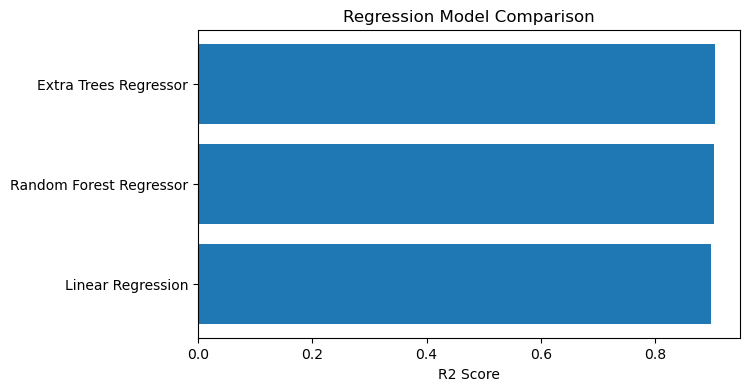

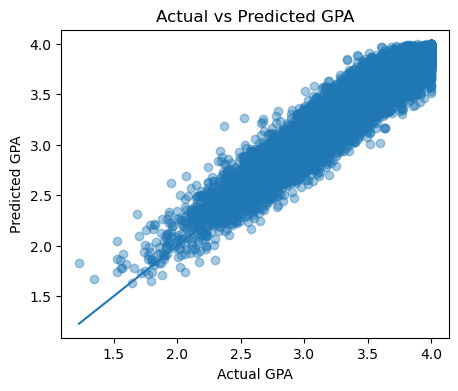

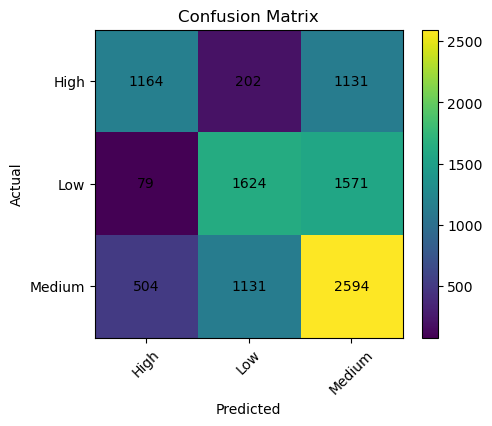

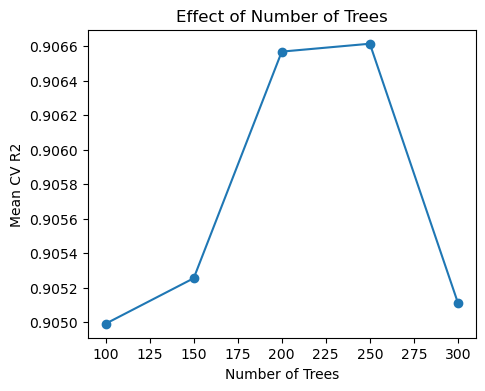

In [10]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(7, 4))
plt.barh(regression_results_df["Model"], regression_results_df["R2 Score"])
plt.title("Regression Model Comparison")
plt.xlabel("R2 Score")
plt.show()

plt.figure(figsize=(5, 4))
plt.scatter(yr_test, final_regression_pred, alpha=0.4)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()])
plt.title("Actual vs Predicted GPA")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.show()

class_labels = best_classification_model.named_steps["model"].classes_

cm = confusion_matrix(
    yc_test,
    final_classification_pred,
    labels=class_labels
)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

regression_cv_results = pd.DataFrame(regression_focused_search.cv_results_)

tuning_plot = regression_cv_results.groupby(
    "param_model__n_estimators"
)["mean_test_score"].mean().reset_index()

plt.figure(figsize=(5, 4))
plt.plot(tuning_plot["param_model__n_estimators"], tuning_plot["mean_test_score"], marker="o")
plt.title("Effect of Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Mean CV R2")
plt.show()

**Visualization Insights:**

Extra Trees Regressor had the bestperformance. We have 3 visualisations showing the comparison of 3 diff models. 

The confusion matrix shows that burnout classification was much harder, with alot of the values being misclassified. 

The number of trees didn't make much of a difference, but we can see that 175-275 trees gives the best results on the model.

## 10. Conclusion

This project/notebook evaluated burnout risk and post semester GPA using classification and regression respectively. 

The main regression task focused on predicting `Post_Semester_GPA`. The best model was the tuned Extra Trees Regressor, which achieved an R² score of 0.9092 and RMSE of 0.1480. This shows that the model was able to predict GPA values well.

The secondary classification task focused on predicting `Burnout_Risk_Level`. The best model was Logistic Regression, with an accuracy and macro F1-score of around 0.5382. This shows that burnout risk was harder to predict than GPA using the available features. We improved from the class baseline of 42%, however we would need more relevant features other than Anxiety levels to make better conclusions and achieve a higher accuracy.

Overall, the dataset was more suitable for predicting academic performance than burnout risk. GPA prediction performed well because features like pre-semester GPA and study-related behaviour had a strong relationship with the target.

**Limitations:**

* Burnout risk was difficult to classify due to lack of relevant features. 
* Some real-world factors were missing, and the data was more suited towards regression of GPA.
* Classification performance was moderate
* Results show correlation, not causation

**Future Improvements:**

* I would add more student background features, and more things regarding mental health for a better score on Burnout Risk
* Try more advanced models like catboost and LightGBM. Due to only being able to use Skilit, we're restrained to a large extent.
* Perform deeper feature importance analysis


## 11. References

* Kaggle Dataset: AI Impact on Students  
  https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students

* scikit-learn Documentation  
  https://scikit-learn.org/stable/

* scikit-learn Pipeline Documentation  
  https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

* scikit-learn ColumnTransformer Documentation  
  https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html

* scikit-learn Model Evaluation Documentation  
  https://scikit-learn.org/stable/modules/model_evaluation.html